In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from IPython.display import Latex
import scipy.signal

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom12_ics_v1/output', 247, basename='snap')
# snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output',
#                    305, basename='snapshot')
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom8/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([5e2, 5e2, 5e2], dtype=float) ## good for testing
# widths = np.array([2e1, 2e1, 2e1], dtype=float)

# test_types = ['diff_of_gaussians','direct_mexican']
# test_type = 



The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)




In [2]:
get_index_cube = pa.util.get_index_of_cubic_region

import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [3]:

# def enforce_hermitian(amplitude_matrix):
#     ## this is for odd matrices
#     amplitudes = amplitude_matrix.copy()
#     Nx, Ny, Nz = amplitudes.shape
#     for kk in range(0,Nz//2):
#         amplitudes[:,:,kk]=np.conj(np.flip(amplitudes)[:,:,kk])
    
#     amplitudes[:Nx//2+1,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,:Ny//2+1,Nz//2])
#     amplitudes[:Nx//2+1,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,Ny//2+1:,Nz//2])
#     amplitudes[Nx//2+1:,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,Ny//2+1:,Nz//2])
#     amplitudes[Nx//2+1:,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,:Ny//2+1,Nz//2])

#     return amplitudes

In [4]:
# def P1d(FFTw, K2, widths):

#     # FFTw and K2 have the same shape:
#     # (Nx,Ny,Nz) (for complex transform)

#     Nx, Ny, Nz = FFTw.shape
#     Lx, Ly, Lz = widths

#     kxmax = (2.0*np.pi/Lx)*(Nx//2)
#     kymax = (2.0*np.pi/Ly)*(Ny//2)
#     kzmax = (2.0*np.pi/Lz)*(Nz//2)


#     kmax = np.sqrt(kxmax**2 + kymax**2 + kzmax**2)
#     kmin = 0
#     nbin = int(kmax/(2.0*np.pi/np.min(widths) ) + 0.5)
#     deltak = 2.0*np.pi/np.min(widths)

#     spectrum_1d = np.zeros(nbin)
#     wavevec = np.arange(nbin)*deltak

#     for i in range(Nx):
#         for j in range(Ny):
#             for k in range(Nz):

#                 m = int( np.floor( pow( K2[i,j,k], 0.5 ) / (deltak) + 0.5 ) )
#                 if (m < nbin):
#                     spectrum_1d[m] += np.real( FFTw[ i,j,k] * np.conj( FFTw[i,j,k] ) ) / (Nx*Ny*Nz)**2

#     spectrum_1d *= (2.*np.pi/deltak)*(Lx*Ly*Lz)

#     energy_fourier_space = np.sum(spectrum_1d*deltak/(2.0*np.pi))
#     print('energy (fourier space) = %.4e'%(energy_fourier_space))
#     return spectrum_1d, wavevec

In [5]:
# cp.cuda.Device(3).use()
# with cp.cuda.Device(3):

# Gauss = snap.uq('G')
arepo_length = snap['0_Coordinates'].uq
density_unit = snap['0_Density'].uq
kpc = snap.uq('kpc')

weight = None

filter_length_max = (widths[0]/10)*np.ones(snap['0_Diameters'].shape)*arepo_length


Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [6]:
epsilon = 1e-3
def extract_turbulent_scalar(snap, sf, variable, filter_length, weight, test_type, 
                             filter_type="mexican-hat", 
                             iterative=False, optimized=True):

    if (filter_type=="mexican-hat"):
        print("With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.")
        
        if (test_type=="direct_mexican"): 
            filt_var = mhat.filter_variable(variable, filter_length, weight=weight, 
                                          filter_type="mexican-hat", iterative=iterative, optimized=optimized)
        
        elif (test_type=="diff_of_gaussians"): 
            filt_var_1 = mhat.filter_variable(variable, filter_length/np.sqrt(1.0+epsilon), weight=weight, 
                                              filter_type="gaussian", iterative=iterative, optimized=True)
            filt_var_2 = mhat.filter_variable(variable, filter_length*np.sqrt(1.0+epsilon), weight=weight, 
                                              filter_type="gaussian", iterative=iterative, optimized=True)
            filt_var = (filt_var_1 - filt_var_2)/epsilon

    else:
        filt_var = mhat.filter_variable(variable, filter_length, weight=weight, 
                                          filter_type=filter_type, iterative=iterative, 
                                      optimized=optimized)

    print("min/max/avg occupancy cartesian tiling %d / %d / %.2f"%(mhat.tile.particles_per_tile.min(),
                                                                    mhat.tile.particles_per_tile.max(),
                                                                    cp.mean(mhat.tile.particles_per_tile)))
    if isinstance(variable, str):
        variable = snap[variable]

        
    smoothVar = variable.copy
    turbVar = np.zeros_like(variable)
    
    smoothVar[mhat.index] = filt_var
    turbVar[mhat.index] = variable[mhat.index] - filt_var

    return smoothVar, turbVar


def volume_integral(snap, sf, qt, indices):
    if isinstance(qt, str):
        qt = snap[qt]
        
    a = np.sum((qt*snap['0_Volume'])[indices])
    # vol = np.sum((snap['0_Volume'])[mhat.indicesFirstPass])
    # a = np.sum((qt*snap['0_Volume'])[mhat.index])
    # vol = np.sum((snap['0_Volume'])[mhat.index])
    return a

In [7]:
class MexicanHatPowerSpectrum(tc.SmoothingFilter):
    def compute_spectrum(self, variable, mask=None, weight=None, optimized=False):
        

        self.kmin = np.sqrt(2.0)/(self.max_search_radius.value/4.1)
        self.kmax = 20.*self.kmin
        k_vec = np.logspace(np.log10(self.kmin), np.log10(self.kmax), 12) 
        power_spectrum = np.zeros(k_vec.shape)

        for i in range(len(k_vec)):
            k = k_vec[i]
            filt_len = (np.sqrt(2.0)/k)*np.ones(snap[variable].shape)*arepo_length

            if (mask==None):
                var_filtered, _ = extract_turbulent_scalar(snap, self, 
                                                          variable, 4.*filt_len, 
                                                          weight, "diff_of_gaussians",
                                                           iterative=False)
                
                var_variance = volume_integral(snap, self, var_filtered**2,
                                              self.indicesFirstPass)
                
            # else:
            #     snap['masked_var'] = snap['variable']*mask

            ## this is the 3D energy spectral density
            power_spectrum[i] = (var_variance.value/k**3)*(np.pi**(3./2.)*2**(11./2.))/(3.*5./2.)

            ## for 1D energy spectral density
            ## (we are assuming S_3D does not depend on the angular variable)
            power_spectrum[i] *= 4.0*np.pi*(k/(2.*np.pi))**2
            
        
        return k_vec, power_spectrum

In [8]:

mhat = MexicanHatPowerSpectrum(snap, center, widths, npix=256, orientation=None, 
                        search_radius=4.1*filter_length_max.value)

In [9]:
# volume_integral(snap, sf, snap['0_synthetic_rhofield']**2)

In [10]:
indices_plus_layer = pa.util.get_index_of_cubic_region_plus_thin_layer(snap['0_Coordinates'], 
                                                                  center, widths*arepo_length, 
                                                                  snap['0_Diameters'].value*arepo_length,
                                                                  snap.box )

In [11]:
indices_no_layer = pa.util.get_index_of_cubic_region(snap['0_Coordinates'], 
                                                                  center, widths*arepo_length, 
                                                                  snap.box )

In [12]:
np.sum(indices_no_layer), np.sum(indices_plus_layer)

(974619, 1031048)

In [13]:
# ## generate Kolmogorov IC
# nmax = 257
# nfreq_tot = nmax**3
# rng = np.random.default_rng(seed=456789)

# x = snap['0_Coordinates'][indices_no_layer][:, 0].value - center[0].value
# y = snap['0_Coordinates'][indices_no_layer][:, 1].value - center[1].value
# z = snap['0_Coordinates'][indices_no_layer][:, 2].value - center[2].value

# kx_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[0])
# ky_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[1])
# kz_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[2])

# KX, KY, KZ = np.meshgrid(kx_vec, ky_vec, kz_vec, sparse=False, indexing='ij')

# K2 = KX**2 + KY**2 + KZ**2 
# phases_rho = 2.0*np.pi*rng.uniform(low=-1.0, high=1.0, size=(nmax,nmax,nmax))

# K2min = (2.0*np.pi/widths[0])**2 + (2.0*np.pi/widths[1])**2 + (2.0*np.pi/widths[2])**2
# # K2min *=9
# power_law_exponent = -5./3.
# # energy per 3D mode \times k^2 = E(k) \sim k^power_law_exponent
# # ==> energy per 3D mode \sim k^[(power_law_exponent-2)/2]
# ampl = np.zeros(K2.shape)
# ampl = np.where(K2>0,np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
# # ampl = np.where(K2==0,10.0,ampl)

# amplitudes_rho = nfreq_tot*ampl*np.exp(1j*phases_rho)     
# amplitudes_rho = enforce_hermitian(amplitudes_rho)

# synthetic_rhofield = np.zeros(snap['0_Density'].shape)
# ## redo this with finufft 
# synthetic_rhofield[indices_no_layer] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x)%(2.*np.pi), 
#                                                         ((2.0*np.pi/widths[1])*y)%(2.*np.pi), 
#                                                         ((2.0*np.pi/widths[2])*z)%(2.*np.pi), 
#                              amplitudes_rho/(nfreq_tot)   , eps=1e-10, isign=-1))
# # synthetic_rhofield[mhat.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x), 
# #                                                         ((2.0*np.pi/widths[1])*y), 
# #                                                         ((2.0*np.pi/widths[2])*z), 
# #                              amplitudes_rho, eps=1e-10, isign=-1))

# snap['0_synthetic_rhofield'] = synthetic_rhofield * density_unit

## The problem here is that the contribution of the thin layer ~hsml around the 
cube is actually very large. For this reason, computing the total mass (or energy) with 
the volume_integral and with the cartesian deposited qty does not lead to the same result.

In [14]:
volume_integral(snap, mhat, snap['0_Density'], 
                indices_no_layer).value

2708.46177351987

In [15]:
volume_integral(snap, mhat, snap['0_Density'], 
                indices_plus_layer).value

2864.271776118665

In [16]:
thin_shell = np.logical_and(indices_plus_layer, np.logical_not(indices_no_layer))

In [17]:
np.sum(thin_shell), np.sum(indices_plus_layer), np.sum(indices_no_layer)

(56429, 1031048, 974619)

In [18]:
volume_integral(snap, mhat, snap['0_Density'], 
                thin_shell).value

155.8100025987951

In [19]:
npoints = 128
depo = tc.DepositCartesianGrid(snap, center, widths, npoints=npoints, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="TSC")

## deposit density to cartesian grid
density_cartesian = depo.deposit_variable('0_Density', weight='0_Volume')

# basic 
powerspectr_depo, k1d_depo, _ = depo.power_spectrum1d(density_cartesian,
                                                     window=scipy.signal.windows.hann)


energy (real space) = 7.1442e-02
energy (fourier space) = 2.8512e-01


In [20]:
np.min(snap['0_Coordinates'][depo.index][:,0]-center[0])

<PaicosQuantity -54629.47988637 arepo_length small_a / small_h>

## WIth kernel_type='NGP' the cell below gives the same result as the volume_integral 
over indices_no_layer. WIth higher-order interpolation this is not true anymore, as 
contribution from nearby cells are now included

In [21]:

voxel = float(depo.tile_widths[0]*depo.tile_widths[1]*depo.tile_widths[2])*snap['0_Volume'].unit
np.sum(density_cartesian*voxel).value

2750.244731343541

In [22]:
np.sum(density_cartesian**2*voxel).value

0.07314307466483701

In [23]:
volume_integral(snap, mhat, snap['0_Density']**2, 
                indices_no_layer).value

0.07264388472292287

In [24]:


k_vec, power_spectrum = mhat.compute_spectrum('0_Density', mask=None, 
                                             weight=None, optimized=False)


With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 5 / 0.17
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 5 / 0.17
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 5 / 0.17
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 5 / 0.17
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 5 / 0.17
With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.
min/max/avg occupancy cartesian tiling 0 / 5 / 0.17
With mexican-hat the first object return

In [25]:
# powerspectrrho, k1d = P1d(amplitudes_rho, K2, widths) 

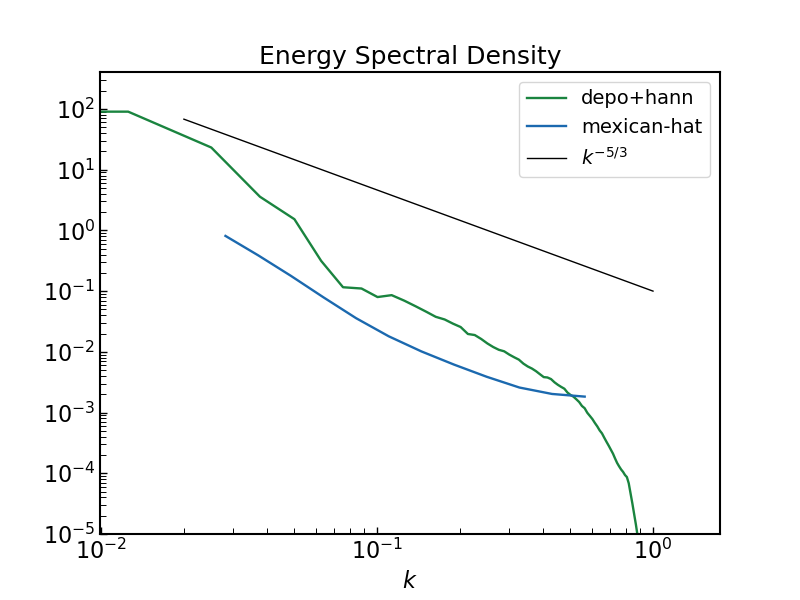

In [29]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(np.log10(2e-2), 0, 100)

# powerspectr_orig, k1d_orig = spectra_var_orig

# ax.plot(k1d_orig.value, powerspectr_orig.value, ls='-', color=grays[6],
#             markerfacecolor='none', label=r'original')

# ax.plot(k1d, powerspectrrho, ls='-', color=reds[2],
#         markerfacecolor='none', label=r'original')

ax.plot(k1d_depo, powerspectr_depo, ls='-', color=greens[2],
        markerfacecolor='none', label=r'depo+hann')

# ax.plot(k_vec, (1./np.pi)*power_spectrum*k_vec**2, ls='-', color=blues[2],
        # markerfacecolor='none', label=r'mexican-hat')
ax.plot(k_vec, power_spectrum, ls='-', color=blues[2],
        markerfacecolor='none', label=r'mexican-hat')

ax.plot(tt, 1e-1*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(ymin=1e-5)

ax.legend(loc='best',ncols=1,fontsize=14)

ax.set_title(r'Energy Spectral Density', fontsize=18)

# ax.set_xlim(xmin=1e-2)
# ax.set_ylim(ymin=1e-25,ymax=1e-11)
# ax.set_ylim(ymin=1e-20)
# ax[1].set_xlim(xmax=30)
# savename = "power_spectrum_%s-%s"%(filter_type, var_type)

plt.savefig('./../../plots/power-spectra/mexican-hat-spectrum-snap.pdf',dpi=400)
